# DrugSpace Quick Tutorial

This notebook shows a minimal end-to-end workflow:
1. Load the pretrained DrugSpace model
2. Encode text into embeddings
3. Build a 2D UMAP visualization colored by ATC class
4. Export MedViz-compatible `tsv` and `meta.json` files

Run cells from top to bottom.

In [8]:
# from llm2vec import LLM2Vec
# import torch
# import torch.nn.functional as F

# Step 1: load pretrained DrugSpace model
l2v = LLM2Vec.from_pretrained(
    base_model_name_or_path="cczzzyyy/DrugSpace-mntp-8B",
    peft_model_name_or_path="cczzzyyy/DrugSpace-full-lora",
    enable_bidirectional=True,
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16,
)

# Quick sanity check on some example texts
texts = [
    # low similarity pair
    "Luminatrex is a small-molecule agent indicated for chronic inflammatory disorders that selectively inhibits intracellular signaling involved in cytokine production.",
    "Glycemorin is a synthetic therapeutic used for metabolic dysfunction that is thought to improve insulin sensitivity and reduce hepatic glucose output.",

    # high similarity pair
    "Atorvastatin is used to treat elevated cholesterol levels and to lower the risk of cardiovascular events such as heart attack and stroke. By decreasing cholesterol synthesis in the liver, it helps reduce circulating LDL concentrations.",
    "Simvastatin is a lipid-modifying agent for patients with primary hypercholesterolemia. The drug is administered to improve serum lipoprotein profiles, with its therapeutic effect arising from competitive inhibition of 3-hydroxy-3-methylglutaryl-coenzyme A reductase.",
]

emb = l2v.encode(texts, show_progress_bar=True)

sim_low = F.cosine_similarity(emb[0].unsqueeze(0), emb[1].unsqueeze(0)).item()
sim_high = F.cosine_similarity(emb[2].unsqueeze(0), emb[3].unsqueeze(0)).item()

print("Low-similarity pair:", round(sim_low, 4))
print("High-similarity pair:", round(sim_high, 4))

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Low-similarity pair: 0.3686
High-similarity pair: 0.6843


## Step 2: DrugBank embeddings -> UMAP

Now we run the model on DrugBank descriptions and project embeddings to 2D with UMAP.

Before running this step, download the [DrugBank](https://go.drugbank.com/releases/latest) data and perform basic preprocessing with:

```bash
python data_process/parse_drugbank.py \
  --input "data/full database v5_1_14.xml" \
  --output data/full_data_anc.csv
```

In [10]:
import numpy as np
import pandas as pd
import umap

# Load DrugBank data and keep rows with ATC labels
DATA_PATH = "data/full_data_anc.csv"
df = pd.read_csv(DATA_PATH)
df = df[df["description"].notna() & df["atc_name"].notna()].copy()

# Encode text with the already-loaded model: l2v
texts = df["description"].astype(str).tolist()
X = np.asarray(l2v.encode(texts, show_progress_bar=True))
print("Embeddings:", X.shape)

# Project to 2D with UMAP
Y = umap.UMAP(
    n_neighbors=50,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
).fit_transform(X)
df["umap_x"] = Y[:, 0]
df["umap_y"] = Y[:, 1]
print("UMAP coords added:", df[["umap_x", "umap_y"]].shape)

Batches:   0%|          | 0/95 [00:00<?, ?it/s]

Embeddings: (3030, 4096)


/gpfs/radev/home/zc347/.conda/envs/llm2vec_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/gpfs/radev/home/zc347/.conda/envs/llm2vec_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP coords added: (3030, 2)


## Step 3: Color points by ATC and plot

We assign one color per ATC class and visualize the 2D UMAP points.

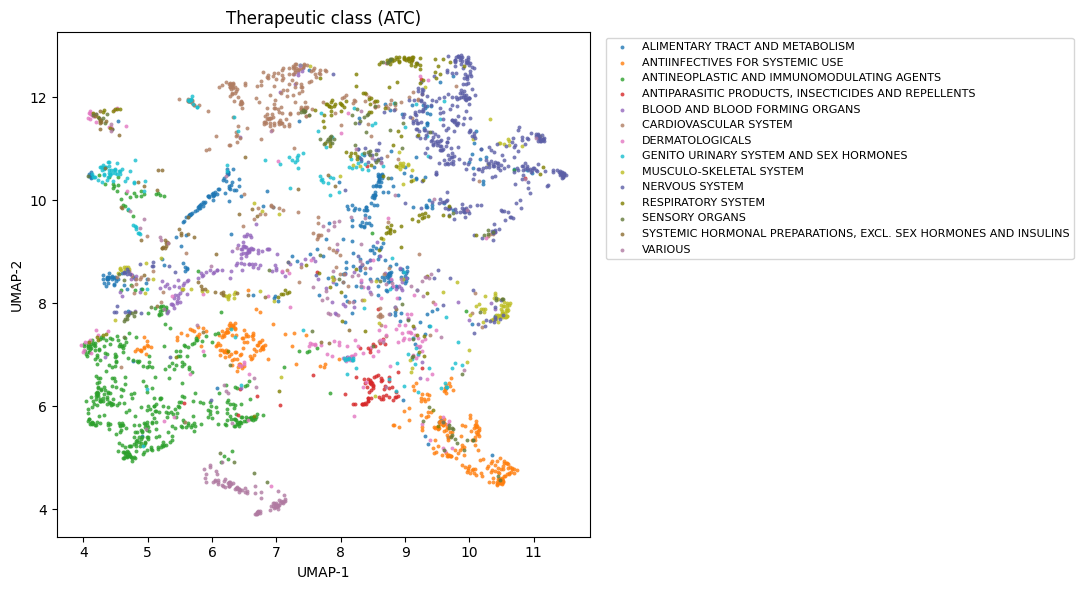

In [14]:
import matplotlib.pyplot as plt

MISSING_COLOR = "#d9d9d9"
ATC_COLOR_MAP = {
    "ALIMENTARY TRACT AND METABOLISM": "#1f77b4",
    "ANTIINFECTIVES FOR SYSTEMIC USE": "#ff7f0e",
    "ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS": "#2ca02c",
    "ANTIPARASITIC PRODUCTS, INSECTICIDES AND REPELLENTS": "#d62728",
    "BLOOD AND BLOOD FORMING ORGANS": "#9467bd",
    "CARDIOVASCULAR SYSTEM": "#b07d62",
    "DERMATOLOGICALS": "#e377c2",
    "GENITO URINARY SYSTEM AND SEX HORMONES": "#17becf",
    "MUSCULO-SKELETAL SYSTEM": "#bcbd22",
    "NERVOUS SYSTEM": "#5b5ea6",
    "RESPIRATORY SYSTEM": "#7f7f00",
    "SENSORY ORGANS": "#637939",
    "SYSTEMIC HORMONAL PREPARATIONS, EXCL. SEX HORMONES AND INSULINS": "#8c6d31",
    "VARIOUS": "#b07aa1",
    "Unknown": MISSING_COLOR,
}

def norm_label(x):
    if pd.isna(x) or str(x).strip() == "":
        return "Unknown"
    return str(x).strip()

labels = df["atc_name"].map(norm_label)
color_map = dict(ATC_COLOR_MAP)
fallback = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#76b7b2", "#edc948"]
fi = 0
for lab in pd.unique(labels):
    if lab not in color_map:
        color_map[lab] = fallback[fi % len(fallback)] if lab != "Unknown" else MISSING_COLOR
        fi += 1

ordered_labels = [k for k in ATC_COLOR_MAP if k in set(labels) and k != "Unknown"]
ordered_labels += sorted([k for k in set(labels) if k not in ATC_COLOR_MAP and k != "Unknown"])
if "Unknown" in set(labels):
    ordered_labels += ["Unknown"]

df["color"] = labels.map(color_map)

x = df["umap_x"].to_numpy()
y = df["umap_y"].to_numpy()
lab_np = labels.to_numpy()

fig, ax = plt.subplots(figsize=(11, 6))

m_unknown = lab_np == "Unknown"
ax.scatter(x[m_unknown], y[m_unknown], s=8, alpha=0.5, c=[MISSING_COLOR], linewidths=0, zorder=1)
for lab in ordered_labels:
    if lab == "Unknown":
        continue
    m = lab_np == lab
    ax.scatter(x[m], y[m], s=8, alpha=0.8, c=[color_map[lab]], linewidths=0, zorder=2, label=lab)

ax.set_title("Therapeutic class (ATC)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

## Step 4: Export MedViz files

This creates:
- `drugspace_part_viz_atc_name.tsv`
- `drugspace_part_viz_atc_name.meta.json`

In [ ]:
import json
from datetime import date
from pathlib import Path

dataset_id = "drugspace_part_viz_atc_name"
out_dir = Path("drugspace_color_outputs")
out_dir.mkdir(exist_ok=True)

tsv_name = f"{dataset_id}.tsv"
meta_name = f"{dataset_id}.meta.json"

df.to_csv(out_dir / tsv_name, sep="\t", index=False)

meta = {
    "dataset_id": dataset_id,
    "dataset_slug": f"medviz/{dataset_id}",
    "type": "PRE_GENERATED",
    "status": "COMPLETED",
    "datetime_created": date.today().isoformat(),
    "datetime_updated": date.today().isoformat(),
    "title": "Therapeutic class (ATC)",
    "description": "DrugSpace embedding visualization colored by therapeutic class (ATC)",
    "url": tsv_name,
    "total_records": int(len(df)),
    "data_uris": {
        "points_data_uri": f"/dataset/medviz/{tsv_name}",
        "topics_data_uri": None,
    },
    "config": {
        "color_scale": "by_attr_color",
        "size_scale": "by_size_attribute",
        "color_legend": [{"color": color_map[k], "label": k} for k in ordered_labels],
    },
}

with open(out_dir / meta_name, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=4)

print(f"Saved: {tsv_name}")
print(f"Saved: {meta_name}")